In [1]:
import numpy as np
import pandas as pd

In [10]:
data1 = pd.read_csv('patient_records.csv')
data1.head()

,patient_id,first_name,last_name,gender,age,blood_type,state,smoking_status,insurance_type,primary_condition,height_cm,weight_kg,systolic_bp,diastolic_bp,heart_rate_bpm,last_admission_date
0,PT100000,Sarah,Jackson,Male,0,O+,CA,Former,Private,Type 2 Diabetes,152.3,81.8,71,58,75,2024-07-19
1,PT100001,Jessica,Smith,Female,53,O+,PA,Former,Medicaid,Anxiety Disorder,183.2,45.6,114,89,75,2025-01-16
2,PT100002,John,Nguyen,Male,70,A+,PA,Never,Private,Asthma,178.1,66.5,104,71,66,2023-10-11
3,PT100003,Robert,Brown,Male,52,O+,PA,Former,Medicare,Chronic Kidney Disease,171.5,NaN,147,77,99,2023-08-09
4,PT100004,Priya,Rossi,Female,36,O+,AZ,Never,Medicaid,Type 2 Diabetes,169.7,65.0,117,59,72,2024-11-15


In [14]:
data1.shape

(1200, 16)

In [15]:
data1.isnull().sum()

patient_id              0
first_name              0
last_name               0
gender                  0
age                     0
blood_type             55
state                   0
smoking_status         52
insurance_type          0
primary_condition       5
height_cm              53
weight_kg              48
systolic_bp             0
diastolic_bp            0
heart_rate_bpm          0
last_admission_date     0
dtype: int64

In [16]:
data1.dropna(inplace=True)

In [17]:
data1.isnull().sum()

patient_id             0
first_name             0
last_name              0
gender                 0
age                    0
blood_type             0
state                  0
smoking_status         0
insurance_type         0
primary_condition      0
height_cm              0
weight_kg              0
systolic_bp            0
diastolic_bp           0
heart_rate_bpm         0
last_admission_date    0
dtype: int64

In [18]:
data1.shape

(997, 16)

In [88]:
X=data1[['age', 'weight_kg']]
X

,age,weight_kg
0,0,81.8
1,53,45.6
2,70,66.5
4,36,65.0
5,78,100.9
...,...,...
1193,54,70.2
1194,23,70.6
1196,32,83.8
1197,52,66.0


In [89]:
X.isnull().sum()

age          0
weight_kg    0
dtype: int64

In [90]:
Y=data1['systolic_bp']
Y

0        71
1       114
2       104
4       117
5       115
       ... 
1193    115
1194    117
1196    146
1197    132
1199    112
Name: systolic_bp, Length: 997, dtype: int64

In [91]:
print(X.shape)
print(Y.shape)

(997, 2)
(997,)


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2)
X_train, X_test, Y_train, Y_test

(      age  weight_kg
 692    68       75.1
 460    18       74.7
 1106   79       78.6
 1065   71      103.4
 354    94       72.1
 ...   ...        ...
 1152   89       81.9
 305    27       84.3
 191    35       73.4
 232    86       59.9
 623    18       69.8
 
 [797 rows x 2 columns],
      age  weight_kg
 487    6      101.6
 836   34       91.9
 873   38       94.0
 802   73       76.2
 561   40       83.7
 ..   ...        ...
 585   61       67.7
 731   43       93.5
 574    1       37.7
 91    25       71.5
 776   58       80.6
 
 [200 rows x 2 columns],
 692     146
 460     103
 1106    112
 1065    124
 354     135
        ... 
 1152    139
 305     143
 191     134
 232     153
 623     176
 Name: systolic_bp, Length: 797, dtype: int64,
 487    128
 836    119
 873    124
 802    139
 561    127
       ... 
 585    105
 731    109
 574    113
 91     118
 776    137
 Name: systolic_bp, Length: 200, dtype: int64)

In [93]:
print(X_train.columns.tolist())

['age', 'weight_kg']


In [94]:
X_train

,age,weight_kg
692,68,75.1
460,18,74.7
1106,79,78.6
1065,71,103.4
354,94,72.1
...,...,...
1152,89,81.9
305,27,84.3
191,35,73.4
232,86,59.9


In [95]:
X_test

,age,weight_kg
487,6,101.6
836,34,91.9
873,38,94.0
802,73,76.2
561,40,83.7
...,...,...
585,61,67.7
731,43,93.5
574,1,37.7
91,25,71.5


In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()

In [98]:
X_train=scaler.fit_transform(X_train)
X_train

array([[ 0.73788738,  0.03008087],
       [-1.05760704,  0.00485788],
       [ 1.13289615,  0.25078209],
       ...,
       [-0.44713894, -0.07711686],
       [ 1.38426537, -0.92839295],
       [-1.05760704, -0.30412382]], shape=(797, 2))

In [99]:
X_test=scaler.fit_transform(X_test)
X_test

array([[-1.47923880e+00,  1.65088998e+00],
       [-4.43901056e-01,  1.05435688e+00],
       [-2.95995665e-01,  1.18350322e+00],
       [ 9.98176511e-01,  8.88342331e-02],
       [-2.22042969e-01,  5.50071165e-01],
       [ 9.61200163e-01, -4.83099563e-01],
       [-7.76688187e-01, -8.95107140e-02],
       [-1.40528610e+00, -2.37106532e-01],
       [-5.54830100e-01,  1.15890392e+00],
       [-2.59019317e-01, -5.07698866e-01],
       [ 4.43531293e-01,  7.34565938e-01],
       [ 3.67914661e-02,  1.50363240e-02],
       [ 1.33096364e+00, -8.33608882e-02],
       [-8.50640883e-01, -2.81388353e+00],
       [ 1.22003460e+00,  2.79478832e-01],
       [-8.13664535e-01,  8.69862105e-01],
       [-1.03552262e+00, -2.49406184e-01],
       [ 6.65389380e-01, -1.20262918e+00],
       [ 9.98176511e-01, -9.44336495e-01],
       [ 9.61200163e-01,  1.76158684e+00],
       [ 1.70072712e+00, -4.83099563e-01],
       [-9.24593578e-01, -6.79893987e-01],
       [ 1.84696858e-01,  1.02360775e+00],
       [-1.

In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
clf=LogisticRegression()

In [102]:
clf.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [103]:
clf.predict(X_test)

array([131, 127, 127, 128, 127, 125, 127, 117, 127, 127, 127, 127, 128,
       151, 128, 127, 117, 125, 125, 133, 123, 117, 127, 117, 125, 117,
       117, 127, 117, 117, 117, 127, 110, 133, 131, 128, 117, 127, 133,
       133, 127, 133, 125, 128, 127, 127, 127, 127, 127, 133, 127, 133,
       125, 117, 123, 127, 117, 117, 117, 125, 125, 117, 125, 127, 127,
       127, 127, 133, 125, 127, 125, 128, 125, 127, 128, 127, 117, 117,
       133, 127, 127, 117, 128, 123, 133, 127, 128, 123, 133, 117, 117,
       125, 127, 141, 127, 117, 123, 117, 128, 128, 117, 123, 127, 127,
       123, 127, 127, 131, 123, 127, 127, 127, 133, 125, 125, 127, 127,
       133, 123, 125, 117, 127, 133, 133, 117, 127, 117, 128, 127, 133,
       141, 127, 127, 128, 127, 117, 127, 117, 125, 127, 133, 110, 133,
       117, 110, 151, 127, 127, 123, 128, 127, 117, 128, 127, 125, 123,
       127, 127, 131, 133, 123, 127, 127, 125, 117, 131, 125, 125, 131,
       127, 133, 128, 133, 133, 131, 151, 151, 127, 131, 123, 12

In [104]:
Y_test

487    128
836    119
873    124
802    139
561    127
      ... 
585    105
731    109
574    113
91     118
776    137
Name: systolic_bp, Length: 200, dtype: int64

In [105]:
Y_pred=clf.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score

In [107]:
accuracy_score(Y_test, Y_pred)

0.02

In [108]:
from mlxtend.plotting import plot_decision_regions

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

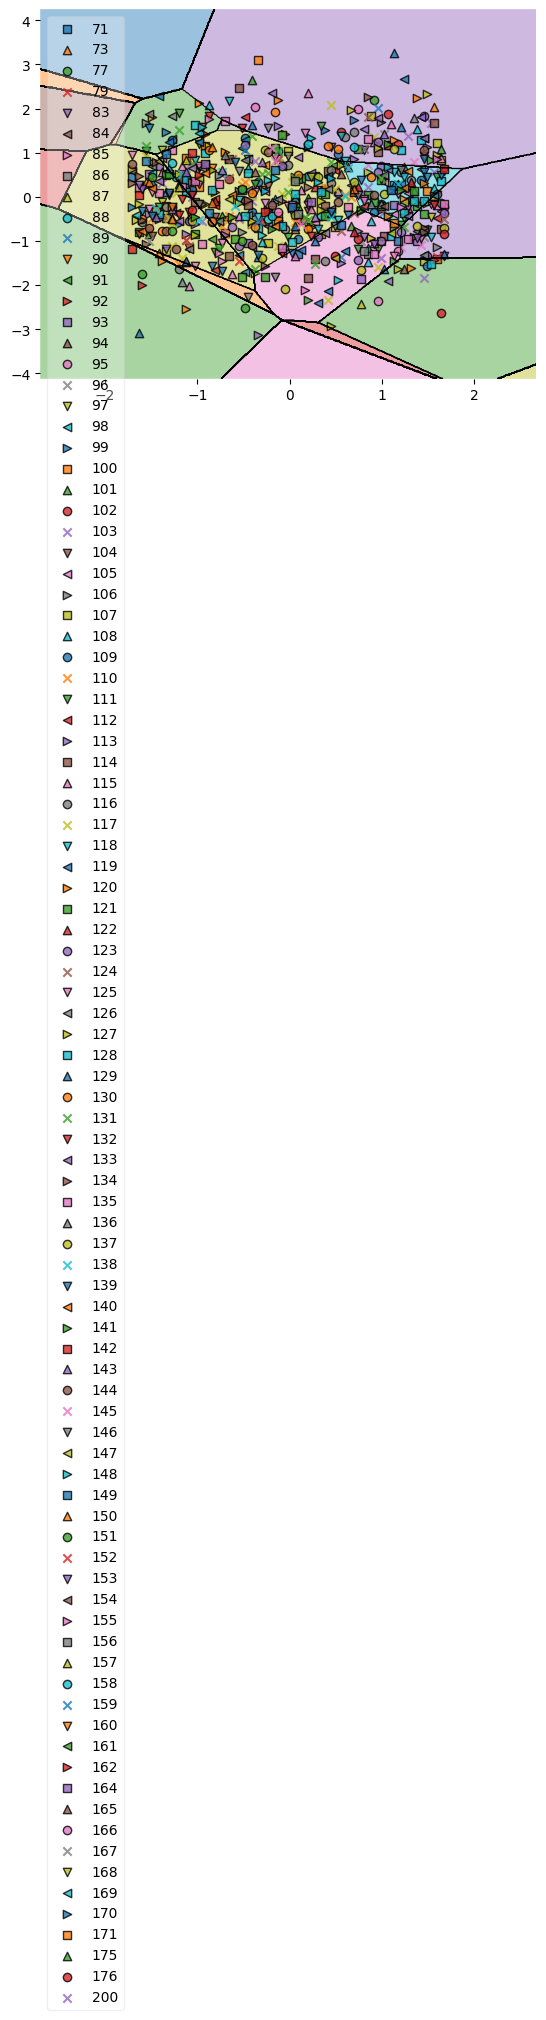

In [109]:
plot_decision_regions(X_train, Y_train.values,clf=clf, legend=2)